# [Demo] Human-in-the-loop

Um agendamento de consulta muda um estado real: ocupa um horário, compromete a agenda de um médico.
Guardrail nenhum resolve isso, porque a chamada não é maliciosa nem tenta vazar dado de ninguém. O
problema é outro: a ação é legítima, mas talvez mereça uma confirmação antes de acontecer de verdade.

O que vamos ver:
- uma política pura decidindo quando um agendamento precisa de aprovação;
- `HumanInTheLoopMiddleware` pausando o agente antes da chamada, com o checkpointer guardando esse estado;
- o ciclo `interrupt` → `Command(resume=...)`, aprovando, editando ou rejeitando a mesma pausa;
- por que um `wrap_tool_call` genérico empilhado junto não interfere na pausa.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from collections.abc import Callable

from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware, wrap_tool_call
from langchain.messages import HumanMessage, ToolMessage
from langchain.tools import tool
from langchain.tools.tool_node import ToolCallRequest
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

## A tool e a política de aprovação

`schedule_appointment` agenda uma consulta, sem checar nada além dos dados recebidos. Quem decide se isso
precisa de aprovação é uma função separada da tool e do middleware: `needs_approval` olha só o argumento
`specialty` e devolve `True` ou `False`. Cardiologia pede aprovação; dermatologia e clínica geral agendam
direto.

In [4]:
@tool
def schedule_appointment(specialty: str, date: str, time: str) -> str:
    """Agenda uma consulta na Clínica Alura pra uma especialidade, data e horário."""
    return f"Consulta de {specialty} agendada pra {date} às {time}."

In [7]:
def needs_approval(request: ToolCallRequest) -> bool:
    specialty = request.tool_call["args"].get("specialty", "")
    return specialty.lower() == "cardiologia"

In [8]:
APPROVAL_POLICY = {
    "schedule_appointment": {
        "description": "Agendamento de cardiologia precisa de aprovação antes de confirmar.",
        "allowed_decisions": ["approve", "edit", "reject"],
        "when": needs_approval,
    }
}

## Pausando antes de agendar

`HumanInTheLoopMiddleware` usa `APPROVAL_POLICY` pra saber quando pausar. A pausa só sobrevive entre uma
chamada e outra porque existe um checkpointer guardando o estado da execução: aqui, um `InMemorySaver`,
suficiente pra este exemplo isolado.

In [9]:
hitl_agent = create_agent(
    model=model,
    tools=[schedule_appointment],
    system_prompt=(
        "Você é o assistente da Clínica Alura. Agende consultas quando pedido. Se a data ou o horário "
        "confirmados forem diferentes do que o paciente pediu, avise isso explicitamente na resposta."
    ),
    middleware=[HumanInTheLoopMiddleware(interrupt_on=APPROVAL_POLICY)],
    checkpointer=InMemorySaver(),
)

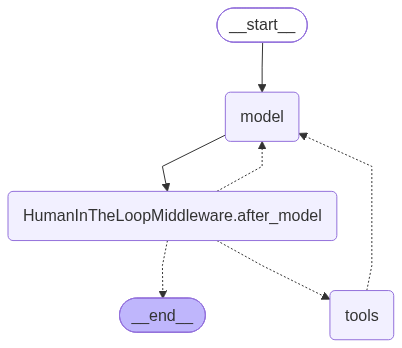

In [10]:
display(Image(hitl_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

`HumanInTheLoopMiddleware.after_model` aparece como um nó próprio, entre `model` e `tools`: mesmo pausando
antes de uma tool específica, o mecanismo por baixo é um hook de nó, rodando logo depois do modelo propor
a chamada, antes da execução da tool começar.

## Cardiologia pausa, dermatologia não

Cada thread guarda seu próprio checkpoint, então cada pedido roda numa `thread_id` diferente.

In [11]:
config_cardio = {"configurable": {"thread_id": "consulta-cardio"}}
result_cardio = hitl_agent.invoke(
    input={"messages": [HumanMessage("Quero agendar uma consulta de cardiologia pro dia 25/08/2026 às 10h")]},
    config=config_cardio,
)
pending = result_cardio["__interrupt__"][0]
print(pending.value)

{'action_requests': [{'name': 'schedule_appointment', 'args': {'specialty': 'cardiologia', 'date': '2026-08-25', 'time': '10:00'}, 'description': 'Agendamento de cardiologia precisa de aprovação antes de confirmar.'}], 'review_configs': [{'action_name': 'schedule_appointment', 'allowed_decisions': ['approve', 'edit', 'reject']}]}


A execução pausou: `pending.value` traz `action_requests`, com o nome e os argumentos da chamada proposta,
e `review_configs`, com as decisões permitidas pra ela (`approve`, `edit`, `reject`, as mesmas de
`APPROVAL_POLICY`). Nada foi executado ainda.

In [12]:
config_derma = {"configurable": {"thread_id": "consulta-derma"}}
result_derma = hitl_agent.invoke(
    input={"messages": [HumanMessage("Quero agendar uma consulta de dermatologia pro dia 26/08/2026 às 14h")]},
    config=config_derma,
)
print(result_derma.get("__interrupt__"))
print(result_derma["messages"][-1].content)

None
A sua consulta de dermatologia foi agendada para o dia 26/08/2026 às 14h.


Dermatologia não bate com a política, então `needs_approval` devolve `False` e o agendamento acontece
direto: sem `__interrupt__`, e a resposta final já confirma a consulta marcada.

## Aprovando ou rejeitando

Retomar uma pausa usa `Command(resume=...)` na mesma `thread_id`, com a decisão pra cada chamada
pendente, em vez de mandar uma mensagem nova.

In [13]:
approved = hitl_agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config_cardio,
)
print(approved["messages"][-1].content)

A sua consulta de cardiologia foi agendada para o dia 25/08/2026 às 10h. 


In [14]:
approved

{'messages': [HumanMessage(content='Quero agendar uma consulta de cardiologia pro dia 25/08/2026 às 10h', additional_kwargs={}, response_metadata={}, id='a528f7b4-8a85-4c36-9bc7-6cb7132bc36a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 124, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1d2403c701', 'id': 'chatcmpl-EK8rwI7YChl92Hb50UhTZK1q9dtp9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06914-af54-7603-920e-fb98881bbcc0-0', tool_calls=[{'name': 'schedule_appointment', 'args': {'spec

Com `approve`, a chamada pausada roda normalmente e o agente confirma o agendamento de cardiologia, do
jeito que confirmaria se não tivesse pausa nenhuma.

In [15]:
config_reject = {"configurable": {"thread_id": "consulta-cardio-reject"}}
result_reject = hitl_agent.invoke(
    {"messages": [HumanMessage("Quero agendar uma consulta de cardiologia pro dia 27/08/2026 às 9h")]},
    config=config_reject,
)
print(result_reject.get("__interrupt__") is not None)

True


In [16]:
rejected = hitl_agent.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "reject",
                    "message": (
                        "O agendamento de cardiologia para 27/08/2026 às 9h não foi aprovado nesta revisão, "
                        "não é uma falha técnica. Avise o paciente que a consulta não foi confirmada e "
                        "pergunte se ele quer tentar outro horário. Não agende de novo sem um novo pedido dele."
                    ),
                }
            ]
        }
    ),
    config=config_reject,
)
print(rejected["messages"][-1].content)

O agendamento da consulta de cardiologia para o dia 27/08/2026 às 9h não foi aprovado. Se desejar, posso ajudar a tentar outro horário ou data. Por favor, me informe a sua preferência!


In [17]:
rejected

{'messages': [HumanMessage(content='Quero agendar uma consulta de cardiologia pro dia 27/08/2026 às 9h', additional_kwargs={}, response_metadata={}, id='13e5c94e-1dea-4094-a6b0-ffda2e31b366'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 124, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1d2403c701', 'id': 'chatcmpl-EK8tpkW8mFrZabGGgv2nKYaJPnNpt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06916-7ef2-7af0-9ebb-01b677d2b70e-0', tool_calls=[{'name': 'schedule_appointment', 'args': {'speci

Com `reject`, a chamada pausada nunca chega a rodar: o agente recebe uma `ToolMessage` de erro no lugar do
resultado da tool, e responde sem confirmar nenhum agendamento, sem tentar de novo sozinho. O `message`
explícito na decisão controla o que o agente lê ali: sem ele, o texto padrão só diz que a chamada foi
rejeitada, sem deixar claro que não foi uma falha técnica, e o agente tende a soar confuso.

## Editando antes de aprovar

`edit` é a terceira decisão de `APPROVAL_POLICY`: a chamada segue adiante, mas com os argumentos que o
revisor definir, não os que o agente propôs. O paciente pede um horário; quem aprova confirma noutro.

In [18]:
config_edit = {"configurable": {"thread_id": "consulta-cardio-edit"}}
result_edit = hitl_agent.invoke(
    {"messages": [HumanMessage("Quero agendar uma consulta de cardiologia pro dia 28/08/2026 às 10h")]},
    config=config_edit,
)
print(result_edit.get("__interrupt__") is not None)

True


In [19]:
edited = hitl_agent.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "edit",
                    "edited_action": {
                        "name": "schedule_appointment",
                        "args": {"specialty": "cardiologia", "date": "28/08/2026", "time": "11:00"},
                    },
                }
            ]
        }
    ),
    config=config_edit,
)
print(edited["messages"][-1].content)

A sua consulta de cardiologia foi agendada para o dia 28/08/2026, mas o horário confirmado é às 11:00, e não às 10:00 como você solicitou. Se precisar ajustar, por favor me avise!


In [20]:
edited

{'messages': [HumanMessage(content='Quero agendar uma consulta de cardiologia pro dia 28/08/2026 às 10h', additional_kwargs={}, response_metadata={}, id='c71b1b7c-869a-4c9a-a432-df62dcf93af6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 124, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1d2403c701', 'id': 'chatcmpl-EK8vpkgqr9ZIkmgPunsmVeW3A5fR3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06918-63b5-71d3-9cc1-bef3c34994df-0', tool_calls=[{'type': 'tool_call', 'name': 'schedule_appoint

O paciente pediu 10h; a consulta foi confirmada às 11h. `schedule_appointment` recebeu o argumento
editado, não o original, e o agente nunca chegou a propor esse novo horário sozinho: quem decidiu foi a
revisão.

## Compondo com retry

Um `wrap_tool_call` genérico, feito pra tentar de novo uma tool que falhar, pode envolver a mesma tool que
o `HumanInTheLoopMiddleware` está pausando. Um contador simples mostra se esse retry chega a rodar
enquanto a execução está pausada.

In [21]:
retry_calls = {"count": 0}

In [22]:
@wrap_tool_call
def counting_retry(request: ToolCallRequest, handler: Callable) -> ToolMessage:
    retry_calls["count"] += 1
    return handler(request)

In [23]:
composed_agent = create_agent(
    model=model,
    tools=[schedule_appointment],
    system_prompt=(
        "Você é o assistente da Clínica Alura. Agende consultas quando pedido. Se a data ou o horário "
        "confirmados forem diferentes do que o paciente pediu, avise isso explicitamente na resposta."
    ),
    middleware=[counting_retry, HumanInTheLoopMiddleware(interrupt_on=APPROVAL_POLICY)],
    checkpointer=InMemorySaver(),
)

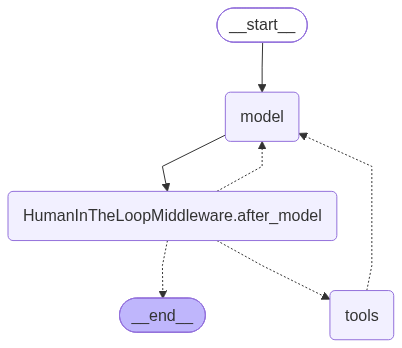

In [24]:
display(Image(composed_agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

No grafo, `HumanInTheLoopMiddleware.after_model` continua como nó; `counting_retry` some, do mesmo jeito
que qualquer hook de envolvimento. Estar antes na lista `middleware=[...]` não muda isso: um hook de
envolvimento sempre fica por dentro do nó `tools`, nunca aparece como nó próprio.

In [25]:
config_compose = {"configurable": {"thread_id": "consulta-compose"}}
result_compose = composed_agent.invoke(
    {"messages": [HumanMessage("Quero agendar cardiologia pro dia 30/08/2026 às 11h")]},
    config=config_compose,
)
print(result_compose.get("__interrupt__") is not None)
print(retry_calls["count"])

True
0


In [26]:
for message in result_compose["messages"]:
    print(message.type, ":", message.content)

human : Quero agendar cardiologia pro dia 30/08/2026 às 11h
ai : 


In [27]:
result_approved_compose = composed_agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config_compose,
)
print(retry_calls["count"])

1


In [28]:
for message in result_approved_compose["messages"]:
    print(message.type, ":", message.content)

human : Quero agendar cardiologia pro dia 30/08/2026 às 11h
ai : 
tool : Consulta de cardiologia agendada pra 2026-08-30 às 11:00.
ai : Sua consulta de cardiologia foi agendada para o dia 30 de agosto de 2026, às 11:00.


O contador ficou em zero enquanto a execução estava pausada: `counting_retry` nunca chegou a rodar, porque
`HumanInTheLoopMiddleware` intercepta antes da cadeia de `wrap_tool_call` da tool alvo sequer começar; a
lista de mensagens confirma isso, sem nenhuma `tool` no meio. Depois do `approve`, o contador sobe pra um,
a chamada normal de `schedule_appointment`, e a `ToolMessage` aparece na lista. Um retry genérico pode
envolver todas as tools, incluindo uma que pausa, sem risco de interferir na pausa.

## Takeaway

`HumanInTheLoopMiddleware` pausa o agente com `interrupt`, guardado no checkpoint da `thread_id` ativa;
`Command(resume={"decisions": [...]})` retoma a partir dali, aprovando, editando ou rejeitando. A política
de quando pausar fica numa função pura, separada do middleware. Um hook de envolvimento como um retry
genérico pode envolver a mesma tool sem disputar espaço com a pausa: os dois mecanismos operam em pontos
diferentes do ciclo do agente.